# Анимация работы сети Петри для задачи "Обедающие философы"

Этот скрипт создаёт анимацию, которая показывает,
как меняется маркировка сети Петри во времени.
Анимация особенно наглядно демонстрирует возникновение deadlock.

## Подготовка окружения

Подключаем DrWatson и активируем проект.

In [1]:
using DrWatson
@quickactivate "project"

Подключаем наш модуль с философами.

In [2]:
include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

using .DiningPhilosophers:
    build_classical_network,
    build_arbiter_network,
    simulate_stochastic,
    detect_deadlock,
    plot_marking_evolution

Подключаем библиотеки для графиков и случайных чисел.

In [3]:
using Plots, Random

## Параметры симуляции

Берём трёх философов, чтобы анимация была проще и нагляднее.

In [4]:
N = 3

3

Симулируем 30 единиц времени.

In [5]:
tmax = 30.0

30.0

Строим классическую сеть Петри.

In [6]:
net, u0, names = build_classical_network(N)

(Main.var"##278".DiningPhilosophers.PetriNet(12, 9, [-1 0 … 0 0; 0 -1 … 1 0; … ; 0 -1 … 1 0; 0 0 … 1 1], [:Think_1, :Think_2, :Think_3, :Hungry_1, :Hungry_2, :Hungry_3, :Eat_1, :Eat_2, :Eat_3, :Fork_1, :Fork_2, :Fork_3], [:GetLeft_1, :GetLeft_2, :GetLeft_3, :GetRight_1, :GetRight_2, :GetRight_3, :PutForks_1, :PutForks_2, :PutForks_3]), [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0], [:Think_1, :Think_2, :Think_3, :Hungry_1, :Hungry_2, :Hungry_3, :Eat_1, :Eat_2, :Eat_3, :Fork_1, :Fork_2, :Fork_3])

Фиксируем seed, чтобы анимация получалась одинаковой при каждом запуске.

In [7]:
Random.seed!(123)

Random.TaskLocalRNG()

Запускаем стохастическую симуляцию.

In [8]:
df = simulate_stochastic(net, u0, tmax)

Row,time,Think_1,Think_2,Think_3,Hungry_1,Hungry_2,Hungry_3,Eat_1,Eat_2,Eat_3,Fork_1,Fork_2,Fork_3
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.217198,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.255714,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.577262,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Создание анимации

Макрос @animate пробегает по каждой строке таблицы результатов
и для каждой строки рисует один кадр.

In [9]:
anim = @animate for row in eachrow(df)


    u = [row[col] for col in propertynames(row) if col != :time]


    bar(
        1:length(u),          # номера позиций по горизонтали
        u,                    # количество фишек по вертикали
        legend = false,       # легенда не нужна, и так много подписей
        ylims = (0, maximum(u0) + 1),  # фиксируем вертикальную шкалу
        xlabel = "Позиция",
        ylabel = "Фишки",
        title = "Время = $(round(row.time, digits=2))",
    )

    xticks!(1:length(u), string.(names), rotation = 45)
end

Could not create decoration from factory! Running with no decorations.


Plots.Animation("/tmp/jl_8ZOtb7", ["000001.png", "000002.png", "000003.png", "000004.png"])

## Сохранение анимации

Собираем все кадры в GIF-файл с частотой 2 кадра в секунду.

[ Info: Saved animation to /home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/plots/philosophers_simulation.gif


Plots.AnimatedGif("/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/plots/philosophers_simulation.gif")
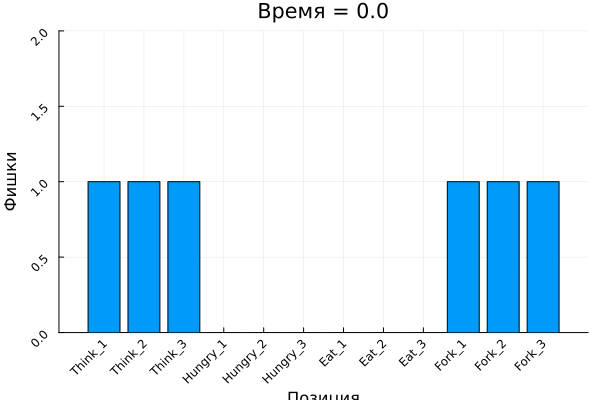

In [10]:
gif(anim, plotsdir("philosophers_simulation.gif"), fps = 2)

Выводим сообщение об успешном сохранении.

In [11]:
println("Анимация сохранена в plots/philosophers_simulation.gif")

Анимация сохранена в plots/philosophers_simulation.gif
